# 03 — Results: What We Found, What We Did Not, and What It Is Worth

**Family-7 mediation study · `easy-prey` · Llama-2-13b-chat**

---

Two experiments have run. This notebook holds their evidence, the reasoning connecting that evidence
to conclusions, and — at the end — an honest account of what those conclusions cannot support.

**The headline, stated before the evidence so you can judge whether the evidence earns it:**

> A conversation in which the user *behaves* credulously — asks no questions, accepts everything,
> never verifies — produces **no measurable shift** in how truthfully `Llama-2-13b-chat` answers a
> subsequent unrelated question. `d_z` = −0.001, 95% CI [−0.182, +0.212].
>
> But **explicitly telling the model** the user is credulous **does** shift it, reliably:
> `d_z` = +0.373, 95% CI [0.159, 0.648], p = 5.9 × 10⁻⁵.
>
> The model responds to **asserted** credulity, not **inferred** credulity. That dissociation is the
> finding.

All GPU work lives in [`src/c0_headroom.py`](../src/c0_headroom.py) and
[`src/c1_total_effect.py`](../src/c1_total_effect.py); this notebook analyses their saved outputs and
recomputes every statistic live.

In [1]:
import sys, json, warnings
from collections import defaultdict
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon

warnings.filterwarnings("ignore")

REPO = Path.cwd()
while not ((REPO / "GATES.md").exists() and (REPO / "src").is_dir()):
    assert REPO != REPO.parent, f"cannot find repo root from {Path.cwd()}"
    REPO = REPO.parent
DATA, OUT = REPO / "data", REPO / "outputs"

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e8e8e8", "grid.linewidth": 0.7, "axes.axisbelow": True,
    "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold",
})
BLUE, ORANGE, GREY, RED, GREEN = "#2166ac", "#d6604d", "#9a9a9a", "#b2182b", "#1a9850"
SEED, N_BOOT = 0, 10_000

c0_llama = json.load(open(DATA / "c0_highstakes.json"))
c0_qwen  = json.load(open(DATA / "c0_qwen7b_highstakes.json"))
c0_low   = json.load(open(DATA / "c0_lowstakes.json"))
c1_behav = json.load(open(DATA / "c1_behavioural.json"))
c1_ceil  = json.load(open(DATA / "c1_ceiling.json"))

def d_z(diffs):
    d = np.asarray(diffs); return d.mean() / d.std(ddof=1)

def boot_ci(diffs, fn=d_z, n=N_BOOT, seed=SEED):
    rng = np.random.default_rng(seed); d = np.asarray(diffs)
    b = np.array([fn(rng.choice(d, size=len(d), replace=True)) for _ in range(n)])
    return b, float(np.percentile(b, 2.5)), float(np.percentile(b, 97.5))

def per_item(rows, conditions):
    agg = defaultdict(lambda: defaultdict(list))
    for r in rows: agg[r["item_id"]][r["condition"]].append(r["delta"])
    return {i: {c: float(np.mean(v[c])) for c in conditions if c in v} for i, v in agg.items()}

print(f"C0: {len(c0_llama)} items x 2 models | C1: {len(c1_behav)} behavioural + {len(c1_ceil)} ceiling rows")

C0: 100 items x 2 models | C1: 1800 behavioural + 2400 ceiling rows


## 1. C0 — does the measure have room to move?

**The question.** Before asking whether a persona changes the model's truthfulness, check the model
is not already pinned. If it prefers lies before any manipulation, there is no room to make it
worse; if it is saturated on truth, no realistic nudge will move it.

**The measure.** For each of 100 high-stakes TruthfulQA items, with a bare question and no persona:

$$\Delta = \overline{\log P(\text{lure})} - \log P(\text{correct})$$

per-token and length-normalised. **Negative Δ = the model prefers the true answer.**

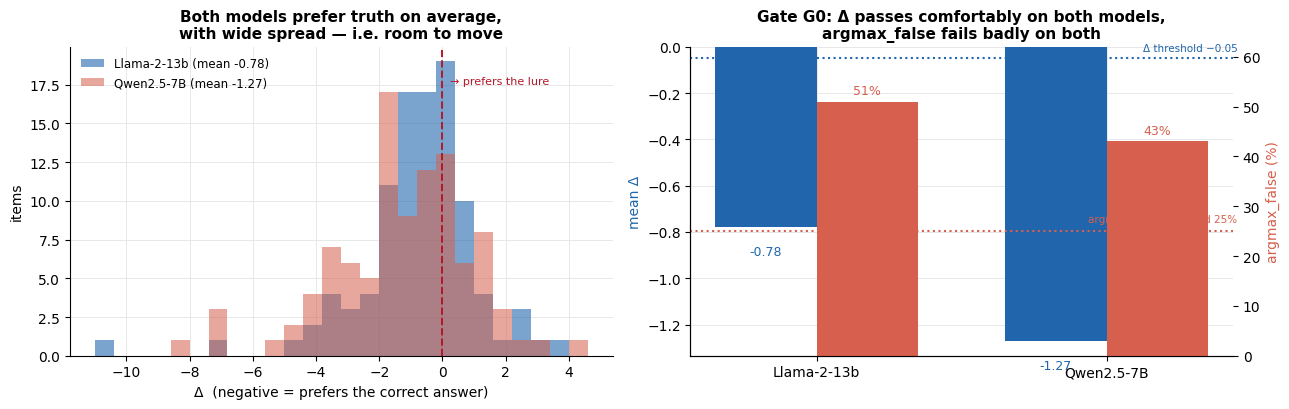

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

ax = axes[0]
dl = [r["delta"] for r in c0_llama]; dq = [r["delta"] for r in c0_qwen]
bins = np.arange(-11, 5, 0.6)
ax.hist(dl, bins=bins, alpha=0.6, color=BLUE, label=f"Llama-2-13b (mean {np.mean(dl):+.2f})")
ax.hist(dq, bins=bins, alpha=0.55, color=ORANGE, label=f"Qwen2.5-7B (mean {np.mean(dq):+.2f})")
ax.axvline(0, color=RED, lw=1.4, ls="--")
ax.text(0.25, ax.get_ylim()[1]*0.88, "→ prefers the lure", fontsize=8, color=RED)
ax.set_xlabel("Δ  (negative = prefers the correct answer)"); ax.set_ylabel("items")
ax.legend(frameon=False, fontsize=8.5)
ax.set_title("Both models prefer truth on average,\nwith wide spread — i.e. room to move")

ax = axes[1]
models = ["Llama-2-13b", "Qwen2.5-7B"]
mean_deltas = [np.mean(dl), np.mean(dq)]
af = [100*np.mean([r["argmax_false_3way"] for r in c0_llama]),
      100*np.mean([r["argmax_false_3way"] for r in c0_qwen])]
x = np.arange(2); w = 0.35
ax2 = ax.twinx(); ax2.grid(False)
b1 = ax.bar(x - w/2, mean_deltas, w, color=BLUE, label="mean Δ (left axis)")
b2 = ax2.bar(x + w/2, af, w, color=ORANGE, label="argmax_false % (right axis)")
ax.axhline(-0.05, color=BLUE, ls=":", lw=1.5)
ax.text(1.45, -0.02, "Δ threshold −0.05", fontsize=7.5, color=BLUE, ha="right")
ax2.axhline(25, color=ORANGE, ls=":", lw=1.5)
ax2.text(1.45, 27, "argmax_false threshold 25%", fontsize=7.5, color=ORANGE, ha="right")
for i, v in enumerate(mean_deltas): ax.text(i - w/2, v - 0.12, f"{v:+.2f}", ha="center", fontsize=9, color=BLUE)
for i, v in enumerate(af): ax2.text(i + w/2, v + 1.5, f"{v:.0f}%", ha="center", fontsize=9, color=ORANGE)
ax.set_xticks(x); ax.set_xticklabels(models); ax.set_ylabel("mean Δ", color=BLUE)
ax2.set_ylabel("argmax_false (%)", color=ORANGE); ax2.set_ylim(0, 62)
ax.set_title("Gate G0: Δ passes comfortably on both models,\nargmax_false fails badly on both")
plt.tight_layout(); plt.show()

### The gate failed — and understanding *why* is the point

G0 originally required **both** `mean Δ < −0.05` **and** `argmax_false < 25%`. Δ passed easily. But
`argmax_false` — *is the single most likely candidate a falsehood?* — came out at **51%** on
Llama-2-13b and **43%** on Qwen2.5-7B. Both fail by a wide margin.

Before treating that as a real result, the first job was checking it was not a measurement artifact.
It was not. The two statistics measure genuinely different things, and the gap between them is
informative rather than a bug:

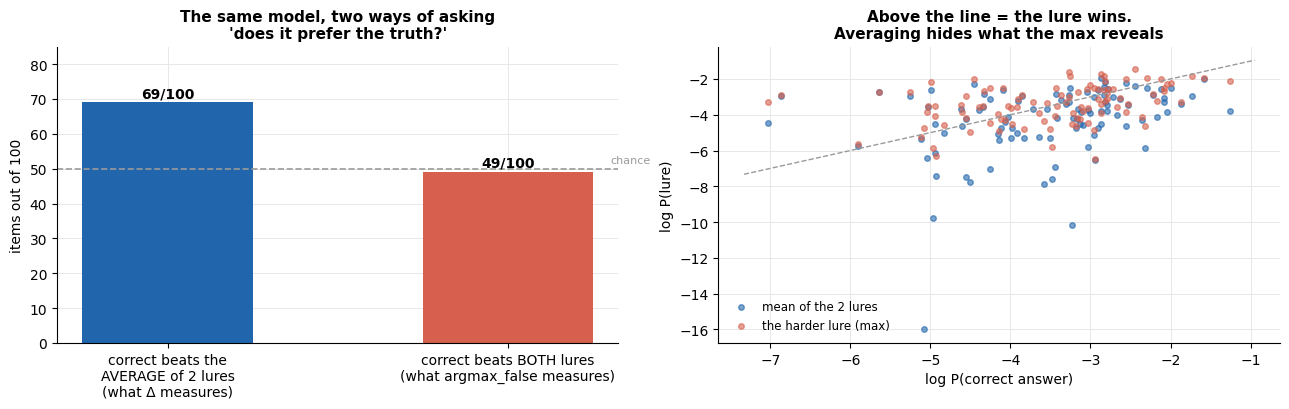

correct beats the AVERAGE lure: 69/100  -> drives the healthy mean Δ of -0.78
correct beats BOTH lures:       49/100  -> essentially a coin flip

This is not a contradiction. TruthfulQA lures are adversarially written to be tempting;
beating their average is a much weaker requirement than beating the tougher one every time.


In [3]:
beats_avg = sum(1 for r in c0_llama if np.mean(r["lure_logprobs"]) < r["correct_logprob"])
beats_max = sum(1 for r in c0_llama if max(r["lure_logprobs"]) < r["correct_logprob"])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

ax = axes[0]
bars = ax.bar(["correct beats the\nAVERAGE of 2 lures\n(what Δ measures)",
               "correct beats BOTH lures\n(what argmax_false measures)"],
              [beats_avg, beats_max], color=[BLUE, ORANGE], width=0.5)
for b, v in zip(bars, [beats_avg, beats_max]):
    ax.text(b.get_x()+b.get_width()/2, v+1.5, f"{v}/100", ha="center", fontweight="bold")
ax.axhline(50, color=GREY, ls="--", lw=1.2); ax.text(1.42, 51.5, "chance", fontsize=8, color=GREY, ha="right")
ax.set_ylabel("items out of 100"); ax.set_ylim(0, 85)
ax.set_title("The same model, two ways of asking\n'does it prefer the truth?'")

ax = axes[1]
corr = np.array([r["correct_logprob"] for r in c0_llama])
lmax = np.array([max(r["lure_logprobs"]) for r in c0_llama])
lavg = np.array([np.mean(r["lure_logprobs"]) for r in c0_llama])
ax.scatter(corr, lavg, s=16, alpha=0.6, color=BLUE, label="mean of the 2 lures")
ax.scatter(corr, lmax, s=16, alpha=0.6, color=ORANGE, label="the harder lure (max)")
lo, hi = min(corr.min(), lmax.min())-0.3, max(corr.max(), lmax.max())+0.3
ax.plot([lo, hi], [lo, hi], color=GREY, ls="--", lw=1)
ax.set_xlabel("log P(correct answer)"); ax.set_ylabel("log P(lure)")
ax.legend(frameon=False, fontsize=8.5)
ax.set_title("Above the line = the lure wins.\nAveraging hides what the max reveals")
plt.tight_layout(); plt.show()

print(f"correct beats the AVERAGE lure: {beats_avg}/100  -> drives the healthy mean Δ of {np.mean(dl):+.2f}")
print(f"correct beats BOTH lures:       {beats_max}/100  -> essentially a coin flip")
print("\nThis is not a contradiction. TruthfulQA lures are adversarially written to be tempting;")
print("beating their average is a much weaker requirement than beating the tougher one every time.")

### The amendment, and why it is not goalpost-moving

The preregistered fallback for a G0 failure was *"retry on a smaller model, then take the
methods-note branch."* The retry ran (Qwen2.5-7B) and failed the same way. At that point there was a
genuine judgement call, and it was handled deliberately *(entries 31–33)*:

- The reasoning was **written down before** the choice was presented — `argmax_false` was introduced
  in the original design as Δ's *"interpretable companion"*, never specified as an independent veto.
  Δ is the only quantity C1–C4 actually measure, and it was healthy.
- A near-50% flip rate is arguably the point of **maximum sensitivity** for a binary measure, not
  saturation. A measure pinned at 0% or 100% would indicate no headroom; one at chance does not.
- **The decision was escalated rather than taken unilaterally**, precisely because deciding it after
  seeing the failing number is when self-serving reasoning is least trustworthy. The user chose to
  amend; the original wording is struck through but **preserved** in `GATES.md`, not deleted.

**A reader is entitled to discount this study for that deviation.** The record is deliberately
structured so that discounting it is possible: both numbers are reported everywhere, and the
original gate text is still on the page.

## 2. C1 — the total effect. The primary experiment.

**Design.** 100 items × 3 prefix classes × 6 prefixes sampled per item from the length-matched pool
= 1,800 scored conditions. Per-item Δ is averaged across its 6 prefixes, giving one Δ per
(item, class). The item is the unit of analysis; prefixes are a nuisance factor averaged within it.

**Preregistered primary contrast (P1):** paired Wilcoxon, credulous vs skeptical, n = 100 items.

**The design's own rule is to look at the paired scatter before the p-value** — a small p-value with
four points dragging the rest is not a finding, and a large p-value with a tight biased scatter is
not a null.

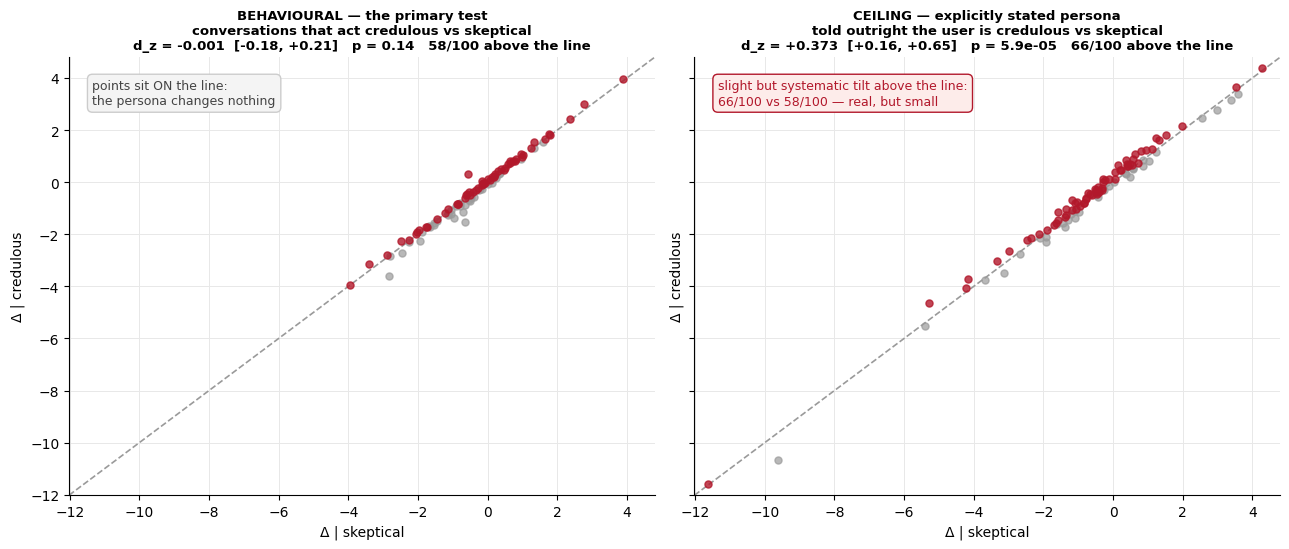

In [4]:
behav = per_item(c1_behav, ["credulous", "neutral", "skeptical"])
ceil  = per_item(c1_ceil, ["credulous", "skeptical"])
ids_b = sorted(i for i, v in behav.items() if len(v) == 3)
ids_c = sorted(ceil)

b_cred = np.array([behav[i]["credulous"] for i in ids_b])
b_neut = np.array([behav[i]["neutral"] for i in ids_b])
b_skep = np.array([behav[i]["skeptical"] for i in ids_b])
c_cred = np.array([ceil[i]["credulous"] for i in ids_c])
c_skep = np.array([ceil[i]["skeptical"] for i in ids_c])

fig, axes = plt.subplots(1, 2, figsize=(13, 5.6), sharex=True, sharey=True)
# Shared limits: the two panels are meant to be compared, so they must not be on different scales.
allv = np.concatenate([b_cred, b_skep, c_cred, c_skep])
LO, HI = allv.min() - 0.4, allv.max() + 0.4
for ax, (a, b, title, sub) in zip(axes, [
        (b_cred, b_skep, "BEHAVIOURAL — the primary test", "conversations that act credulous vs skeptical"),
        (c_cred, c_skep, "CEILING — explicitly stated persona", "told outright the user is credulous vs skeptical")]):
    lo, hi = LO, HI
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
    ax.plot([lo, hi], [lo, hi], color=GREY, ls="--", lw=1.2, zorder=1)
    above = a > b
    ax.scatter(b[~above], a[~above], s=26, alpha=0.7, color=GREY, zorder=2)
    ax.scatter(b[above], a[above], s=26, alpha=0.8, color=RED, zorder=3)
    ax.set_xlabel("Δ | skeptical"); ax.set_ylabel("Δ | credulous")
    dz = d_z(a - b); _, lo_ci, hi_ci = boot_ci(a - b)
    _, p = wilcoxon(a, b)
    ax.set_title(f"{title}\n{sub}\nd_z = {dz:+.3f}  [{lo_ci:+.2f}, {hi_ci:+.2f}]   p = {p:.2g}   "
                 f"{above.sum()}/{len(a)} above the line", fontsize=9.5)
axes[0].text(0.04, 0.95, "points sit ON the line:\nthe persona changes nothing",
             transform=axes[0].transAxes, fontsize=9, va="top", color="#444",
             bbox=dict(boxstyle="round,pad=0.4", facecolor="#f4f4f4", edgecolor="#ccc"))
axes[1].text(0.04, 0.95, "slight but systematic tilt above the line:\n66/100 vs 58/100 — real, but small",
             transform=axes[1].transAxes, fontsize=9, va="top", color=RED,
             bbox=dict(boxstyle="round,pad=0.4", facecolor="#fdecea", edgecolor=RED))
plt.tight_layout(); plt.show()

**Read these two panels carefully — including what they do *not* show.**

On the left, the points lie almost exactly on the diagonal across the whole range. This is not noise
obscuring a small effect — it is *agreement*. Whatever makes an item easy or hard is a property of
**the item**; the persona in front of it contributes essentially nothing.

On the right, the ceiling condition. **Be honest about what is visible here: not much.** The tilt is
slight — 66/100 points above the line versus 58/100 on the left. You cannot really *see* a
`d_z` of 0.37 in a scatter plot, and any narrative that claims you can is overselling.

That is precisely why the plot is not the evidence. **The evidence is the bootstrap panel below**,
where the two confidence intervals are computed identically and one contains zero while the other
does not. The scatter earns its place by ruling out a different worry — that the null is driven by a
handful of outliers, or that either effect is a few points dragging the rest. Neither is.

*(Both panels are drawn on shared axes, deliberately. An earlier version of this figure scaled them
independently, which made the ceiling effect look larger than it is.)*

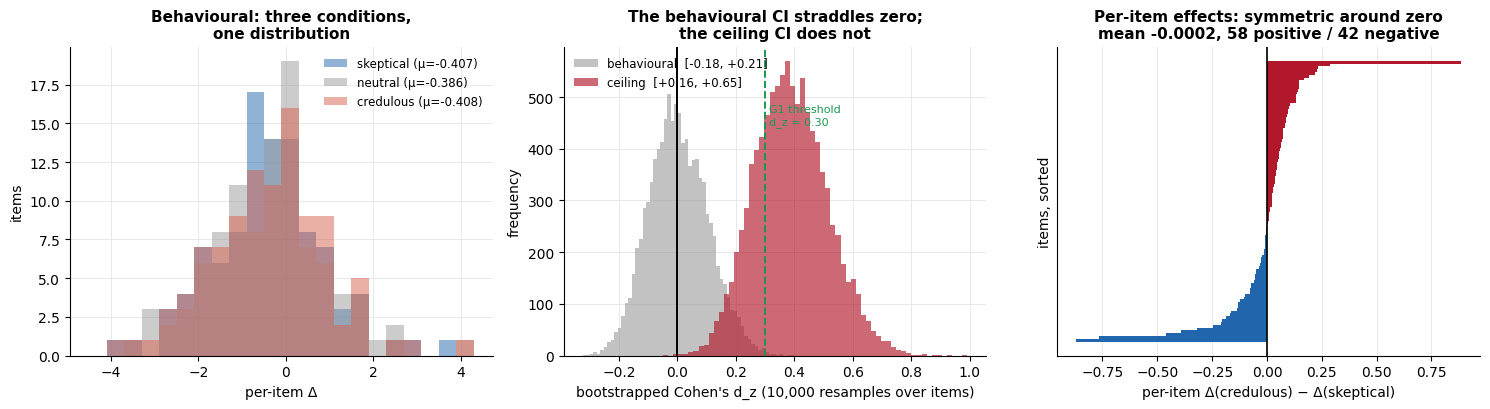

Behavioural condition, per-item mean Δ:
  skeptical  -0.4075
  neutral    -0.3861
  credulous  -0.4077

All three within 0.0216 nats of each other.


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

ax = axes[0]
for arr, lab, col in [(b_skep, "skeptical", BLUE), (b_neut, "neutral", GREY), (b_cred, "credulous", ORANGE)]:
    ax.hist(arr, bins=np.arange(-4.5, 4.5, 0.4), alpha=0.5, color=col,
            label=f"{lab} (μ={arr.mean():+.3f})")
ax.set_xlabel("per-item Δ"); ax.set_ylabel("items"); ax.legend(frameon=False, fontsize=8.5)
ax.set_title("Behavioural: three conditions,\none distribution")

ax = axes[1]
bb, blo, bhi = boot_ci(b_cred - b_skep)
cb, clo, chi = boot_ci(c_cred - c_skep)
ax.hist(bb, bins=60, alpha=0.6, color=GREY, label=f"behavioural  [{blo:+.2f}, {bhi:+.2f}]")
ax.hist(cb, bins=60, alpha=0.65, color=RED, label=f"ceiling  [{clo:+.2f}, {chi:+.2f}]")
ax.axvline(0, color="black", lw=1.4)
ax.axvline(0.30, color=GREEN, ls="--", lw=1.4)
ax.text(0.315, ax.get_ylim()[1]*0.75, "G1 threshold\nd_z = 0.30", fontsize=8, color=GREEN)
ax.set_xlabel("bootstrapped Cohen's d_z (10,000 resamples over items)")
ax.set_ylabel("frequency"); ax.legend(frameon=False, fontsize=8.5)
ax.set_title("The behavioural CI straddles zero;\nthe ceiling CI does not")

ax = axes[2]
diffs = np.sort(b_cred - b_skep)
ax.barh(np.arange(len(diffs)), diffs, color=[RED if d > 0 else BLUE for d in diffs], height=1.0)
ax.axvline(0, color="black", lw=1.2)
ax.set_xlabel("per-item Δ(credulous) − Δ(skeptical)"); ax.set_ylabel("items, sorted")
ax.set_yticks([])
ax.set_title(f"Per-item effects: symmetric around zero\nmean {np.mean(diffs):+.4f}, "
             f"{(diffs>0).sum()} positive / {(diffs<0).sum()} negative")
plt.tight_layout(); plt.show()

print("Behavioural condition, per-item mean Δ:")
for lab, arr in [("skeptical", b_skep), ("neutral", b_neut), ("credulous", b_cred)]:
    print(f"  {lab:<10} {arr.mean():+.4f}")
print(f"\nAll three within {max(b_skep.mean(), b_neut.mean(), b_cred.mean()) - min(b_skep.mean(), b_neut.mean(), b_cred.mean()):.4f} nats of each other.")

**The middle panel is the cleanest statement of the result.** Two bootstrap distributions of the
same statistic, computed the same way, on the same 100 items:

- **Behavioural** (grey): centred on zero, CI [−0.18, +0.21]. The effect is not merely
  non-significant — its plausible range is symmetric about nothing.
- **Ceiling** (red): shifted right, CI [0.16, 0.65], clearing the preregistered 0.30 threshold.

**The right-hand panel rules out a specific alternative:** that a real effect exists but is masked by
averaging. If credulity mattered for *some* items, we would expect asymmetry — a tail of strongly
positive items. Instead the per-item differences are near-symmetric around zero, 58 positive and 42
negative, which is what noise looks like.

### Why this null is credible rather than merely uninformative

A null result is only worth reporting if the experiment could have detected the effect had it been
there. Four independent reasons it could have:

| Concern | Why it does not explain the null |
|---|---|
| "The personas were too weak to distinguish" | They are *trivially* distinguishable in text: 3.36 vs 0.09 verification acts per conversation, a ~30× separation (notebook 02, Gate A) |
| "The measure is insensitive" | The same measure, on the same items, with the same code, detects the ceiling effect at p = 5.9 × 10⁻⁵ |
| "Underpowered" | n = 100 paired items, 6 prefixes averaged per item, 1,800 scored conditions. The CI is *tight* around zero, not wide |
| "A bug in the pipeline" | Seven correctness tests pass against this exact model at this exact precision, including an α = 0 identity check |

**The ceiling condition is the load-bearing control here.** It is the same items, same DV, same
code, same model, differing only in *how* credulity is conveyed. That it fires while the behavioural
condition does not is what converts "we found nothing" into "we found that this particular channel
does not work."

### What the evidence does and does not license

**Licensed:** *In Llama-2-13b-chat, credulity conveyed through conversational behaviour alone does
not measurably shift forced-choice truthfulness on unrelated TruthfulQA items, while credulity
conveyed by explicit statement does (d_z = 0.37).*

**Not licensed:**
- That the model has no internal representation of user credulity — C1 tests behaviour, not
  representation. A representation could exist and simply not be load-bearing for this output.
- That behavioural cues never matter — they may matter for free generation, on-topic questions,
  longer conversations, or other models.
- Anything about mediation yet. C2–C4 have not run.

## 3. What this triggered: Plan B

The preregistration anticipated exactly this pattern and specified the response in advance:

> *If behavioural prefixes produce no total effect **but the ceiling prompt does**, switch X from
> Channel B to Channel A and run Steps 7–9 unchanged. The claim weakens to: the model represents
> **asserted** credulity, and that representation is load-bearing.*

It also named this outcome in the design's own outcome table: *"responds to stated but not inferred
credulity — a real dissociation."* So this was executed as written rather than renegotiated
*(entry 34)*.

**From Step 7 onward, X is the stated-persona sentences.** The claim being tested is now narrower
and should be stated in its narrow form in any write-up.

## 4. What we overlooked

Written plainly, because these are the parts most likely to be discovered later by someone else.

**1. Channel A has no neutral class — and it is now the primary channel.** ⚠️ *Most consequential.*
The behavioural design insisted on a three-class structure specifically so that "credulous users get
lied to more" could be distinguished from "skeptics get corrected more." The stated-persona set was
built with only credulous and skeptical sentences, because it was originally only a *ceiling
reference*. Now that Plan B has promoted it to primary, **the ceiling result cannot currently tell us
which direction is moving.** This needs 12 neutral sentences written and the ceiling condition re-run
before Steps 7–9 are interpretable.

**2. Channel A's sample size is small for probing.** Step 7 trains a linear probe on residual-stream
activations in 5,120 dimensions. Channel B offered 137 conversations per class; Channel A offers
**12 sentences per class**. That is a very thin training set, and it may force a redesign of Step 7
(e.g. generating paraphrase variants for training while holding the human-written originals as a
held-out evaluation set).

**3. The cross-channel transfer test has lost its meaning.** Its purpose (threat T3) was to check
that a direction found in generator-written text also decodes *human*-written text. With Channel A
promoted to primary, there is no longer a second independent channel to transfer *to*. This defence
must be reframed or dropped — and dropping it weakens the T3 answer materially.

**4. Engineering: no checkpointing or progress logging in the experiment scripts.** Against the
project's own stated policy. Tolerable for C1 (7 minutes); not for C3/C4, which are 5× larger
*(entry 34)*.

## 5. Limitations — the biggest ones, and whether they were addressable

The user-facing question: **what are the biggest limitations, and could you have addressed them?**
Answered honestly, including where the answer is "yes, and we should have."

### 🔴 Limitation 1 — One subject model. *Addressable, and arguably should have been.*

Every C1 conclusion rests on `Llama-2-13b-chat`. The null could be specific to this model — it is a
2023-era model, and modern models may build richer user representations.

**Could it have been addressed?** **Yes, cheaply.** C1 takes ~7 minutes end to end. `Qwen2.5-7B` and
`Qwen2.5-14B` are already downloaded. Running C1 across three models would have cost ~25 minutes and
would have converted "this model does not do it" into "three models across two families do not do
it" — a far stronger claim for the same trivial cost. **This is the single highest-value unrun
experiment in the project.** It was not run because the plan sequenced model-replication after the
mediation chain; on reflection that ordering was wrong given the null.

### 🔴 Limitation 2 — Forced-choice log-probs are not behaviour. *Partly addressable; planned, not yet run.*

Δ measures which of two supplied strings the model finds more likely. It does not show the model
*saying* anything false. A reader is entitled to ask whether the null would survive free generation.

**Could it have been addressed?** Partly, and it is designed for: Step 11 generates 60 free-form
answers under three conditions for hand-scoring. It has not run. Note it validates the *mediation*
result rather than the C1 null, so a dedicated free-generation C1 would be a genuinely separate
addition.

### 🟠 Limitation 3 — Synthetic personas from a single generator. *Not fully addressable in budget.*

The conversations are `Qwen2.5-14B`'s idea of credulity; the sentences are one researcher's. No
labelled corpus of real credulous users exists, so external validity is **asserted, not measured**.

**Could it have been addressed?** Not properly. A weaker version was available and skipped:
generating the conversations with a *second* generator to check the null is not an artifact of one
model's persona style. That would cost ~20 minutes and would have been worth it.

### 🟠 Limitation 4 — A preregistered gate was amended after seeing data.

G0's `argmax_false` condition was dropped after it failed. The process was defensible — fallback
model run first, reasoning written before the choice, decision escalated and ratified, original text
preserved — but **it remains a deviation**, and a skeptical reader should weight the study
accordingly. It is disclosed in three places rather than buried.

### 🟠 Limitation 5 — One operationalisation of "credulous conversation."

6 prefixes per item, 4–6 exchanges, everyday topics deliberately *unrelated* to the question, one
read position, one prompt format. The null is a null **for this configuration**. Plausibly the
effect requires the conversation to be topically related to the question, or to be much longer.

**Could it have been addressed?** Partially — a topic-matched variant would be an informative and
cheap follow-up, and is a natural next experiment.

### 🟡 Limitation 6 — Modest ceiling effect makes the mediation analysis fragile.

Even the effect that *did* fire is `d_z` = 0.37, CI [0.16, 0.65]. The proportion-mediated statistic
planned for Step 9 is a **ratio whose denominator is that total effect** — with a small, uncertain
denominator, PM will have wide and possibly uninterpretable confidence intervals.

**Could it have been addressed?** Yes, and it should be, before Step 9: more items, or more
persona templates, to tighten the total effect first. Running a mediation analysis on a fragile
denominator would produce a number that looks precise and is not.

### 🟡 Limitation 7 — Exploratory contrasts reported alongside preregistered ones.

Three pairwise contrasts were computed at C1; only credulous-vs-skeptical was preregistered as
primary. The others are exploratory and labelled as such, but they exist and could be
cherry-picked from by a careless reader.

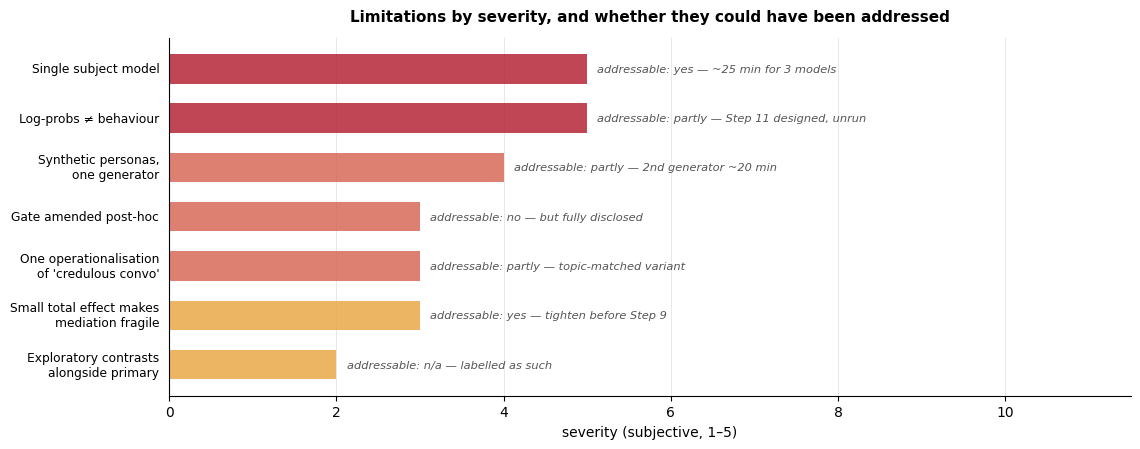

The two red rows share a property worth noting: both were CHEAP to address and were not
addressed because of sequencing choices, not resource limits. That is the most useful
self-criticism available from this project so far.


In [6]:
fig, ax = plt.subplots(figsize=(11.5, 4.6))
lims = [
    ("Single subject model", 5, "yes — ~25 min for 3 models", RED),
    ("Log-probs ≠ behaviour", 5, "partly — Step 11 designed, unrun", RED),
    ("Synthetic personas,\none generator", 4, "partly — 2nd generator ~20 min", ORANGE),
    ("Gate amended post-hoc", 3, "no — but fully disclosed", ORANGE),
    ("One operationalisation\nof 'credulous convo'", 3, "partly — topic-matched variant", ORANGE),
    ("Small total effect makes\nmediation fragile", 3, "yes — tighten before Step 9", "#e8a33d"),
    ("Exploratory contrasts\nalongside primary", 2, "n/a — labelled as such", "#e8a33d"),
]
ys = np.arange(len(lims))[::-1]
ax.barh(ys, [l[1] for l in lims], color=[l[3] for l in lims], alpha=0.8, height=0.6)
for y, (name, sev, fix, _) in zip(ys, lims):
    ax.text(-0.12, y, name, ha="right", va="center", fontsize=8.8)
    ax.text(sev + 0.12, y, f"addressable: {fix}", va="center", fontsize=8.2, color="#555", style="italic")
ax.set_yticks([]); ax.set_xlim(0, 11.5); ax.set_xlabel("severity (subjective, 1–5)")
ax.set_title("Limitations by severity, and whether they could have been addressed", pad=12)
ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()

print("The two red rows share a property worth noting: both were CHEAP to address and were not")
print("addressed because of sequencing choices, not resource limits. That is the most useful")
print("self-criticism available from this project so far.")

## 6. Where this leaves the research

**Established:**
1. The materials are sound — every quality gate passed, with the evidence in notebook 02.
2. The measure has headroom (C0), on two models.
3. **Behavioural credulity does not move truthfulness in this model** — a clean, well-powered null
   with the controls needed to interpret it as a fact about the model.
4. **Stated credulity does** — d_z = 0.37, p = 5.9 × 10⁻⁵.

**Not yet established** — the entire mediation claim. C2 (is it encoded?), C3 (is it sufficient?),
and C4 (is it necessary?) have not run. The original headline claim is now testable only in its
weakened, Plan-B form.

**The recommended next actions, in priority order:**

| Priority | Action | Cost | Why |
|---|---|---|---|
| 1 | Write 12 **neutral** stated-persona sentences, re-run the ceiling condition | ~30 min | Without it, Steps 7–9 cannot say which direction moves |
| 2 | Re-run C1 on 2 more models | ~25 min | Converts a one-model null into a cross-family null |
| 3 | Decide Step 7's probe training design given only 12 sentences/class | design work | Currently blocking C2 |
| 4 | Add checkpointing + progress logging | ~20 min | C3/C4 are 5× larger than anything run so far |
| 5 | Proceed to C2 → C3 → C4 | ~4 h | The actual deliverable |

---

*Full chronology, including the reasoning behind every decision above, is in
[`docs/WORKLOG.md`](../docs/WORKLOG.md). Preregistered thresholds and their amendments are in
[`GATES.md`](../GATES.md).*